#Mounting My Drive

In [1]:
#I will satrt by mounting my drive that consist of all of my work
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Imports and Device Info

In [2]:
import sys
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from tqdm import tqdm
import pickle
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy import linalg
import copy
from collections import defaultdict
import time
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB")


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42 GB


#Creating a class for Cinfigiration

In [3]:
class myconfig:
    # 2-class selection
    selected_classes = [0, 1]
    class_names = ['airplane', 'automobile']

    # Model (aligned with repo)
    img_channels = 3
    base_channels = 128
    time_emb_dim = 256
    num_blocks = [2, 2, 2, 2]
    attention_resolutions = [16, 8]

    # Training
    batch_size = 128
    learning_rate = 2e-4
    weight_decay = 1e-4
    gradient_clip = 1.0
    ema_decay = 0.9999

    # Train for 200k steps with checkpoints every 20k
    num_steps = 100100
    checkpoint_every = 20000  # Save at 20k, 40k, 60k, ..., 200k

    # FID evaluation at each checkpoint
    fid_num_samples = 2000  # 2k validation images
    fid_batch_size = 100

    # Optimizer
    adam_betas = (0.9, 0.999)

    # ODE solvers to compare
    solvers = ['euler', 'heun', 'rk4']
    num_steps_list = [10, 20, 50, 100, 500, 1000]

    # Paths are as follows
    save_dir = '/content/drive/MyDrive/FM_coursework'
    checkpoint_dir = os.path.join(save_dir, 'checkpoints')
    validation_dir = os.path.join(save_dir, 'validation_images')
    results_dir = os.path.join(save_dir, 'results')

config = myconfig()
os.makedirs(config.checkpoint_dir, exist_ok=True)
os.makedirs(config.validation_dir, exist_ok=True)
os.makedirs(config.results_dir, exist_ok=True)

print(f"  Config initialized")
print(f"  Classes: {config.class_names}")
print(f"  Training steps: {config.num_steps}")
print(f"  Checkpoint interval: {config.checkpoint_every}")
print(f"  FID samples: {config.fid_num_samples}")


  Config initialized
  Classes: ['airplane', 'automobile']
  Training steps: 100100
  Checkpoint interval: 20000
  FID samples: 2000


#Creating Sinusodial Embeddings

In [4]:
# I am creating Sinusoidal Position Embedding class
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        # Ensure time is 1-D: [B]
        if time.dim() > 1:
            time = time.view(time.size(0))

        device = time.device
        half_dim = self.dim // 2
        scale = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -scale)  # [half_dim]
        emb = time[:, None] * emb[None, :]                               # [B, half_dim]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)                  # [B, dim]
        return emb

#Defining Attention Block

In [5]:
#I will create another class defining Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(32, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    # Modified to accept t_emb but not use it, for consistent calling in UNet
    def forward(self, x, t_emb=None): # Added t_emb=None
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        q = q.reshape(B * self.num_heads, C // self.num_heads, H * W)
        k = k.reshape(B * self.num_heads, C // self.num_heads, H * W)
        v = v.reshape(B * self.num_heads, C // self.num_heads, H * W)

        scale = (C // self.num_heads) ** -0.5
        attn = torch.bmm(q.transpose(-2, -1), k) * scale
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(attn, v.transpose(-2, -1))
        out = out.reshape(B, C, H, W)
        out = self.proj(out)

        return x + out

print("Attention blocks defined")

Attention blocks defined


#Defining my Res Block

In [6]:
#Now further I will be defining Res block
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.norm1 = nn.GroupNorm(32, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.time_proj = nn.Linear(time_emb_dim, out_channels)
        self.norm2 = nn.GroupNorm(32, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(F.silu(t_emb))[:, :, None, None]
        h = F.silu(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.skip(x)

print("ResBlock defined")


ResBlock defined


#Defining U-Net Architecture for Model Loading

In [7]:
class UNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=128, time_emb_dim=256,
                 num_blocks=[2, 2, 2, 2], attention_resolutions=[16, 8]):
        super().__init__()

        self.img_channels = img_channels
        self.base_channels = base_channels
        self.time_emb_dim = time_emb_dim

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # Initial conv
        self.initial_conv = nn.Conv2d(img_channels, base_channels, 3, padding=1)

        # Channel scaling
        channels = [base_channels * (2 ** i) for i in range(len(num_blocks))]

        # Encoder
        self.encoder = nn.ModuleList()
        for i, num_block in enumerate(num_blocks):
            blocks = nn.ModuleList()
            current_in_channels_for_stage = base_channels if i == 0 else channels[i-1]
            target_out_channels_for_stage = channels[i]

            for j in range(num_block):
                in_ch_block = current_in_channels_for_stage if j == 0 else target_out_channels_for_stage
                out_ch_block = target_out_channels_for_stage
                blocks.append(ResBlock(in_ch_block, out_ch_block, time_emb_dim))
                if 32 // (2 ** i) in attention_resolutions:
                    blocks.append(AttentionBlock(out_ch_block))
            self.encoder.append(blocks)

        # Bottleneck
        self.bottleneck = nn.ModuleList()
        bottleneck_ch = channels[-1]
        self.bottleneck.append(ResBlock(bottleneck_ch, bottleneck_ch, time_emb_dim))
        self.bottleneck.append(AttentionBlock(bottleneck_ch))
        self.bottleneck.append(ResBlock(bottleneck_ch, bottleneck_ch, time_emb_dim))

        # Decoder
        self.decoder = nn.ModuleList()
        for i_rev in reversed(range(len(num_blocks))):
            blocks = nn.ModuleList()
            current_stage_channel = channels[i_rev]
            for j in range(num_blocks[i_rev] + 1):
                if j == 0:
                    if i_rev == len(num_blocks) - 1: # Smallest feature map stage
                        in_ch_block = current_stage_channel * 2 # From bottleneck output + skip connection
                    else:
                        # From previous decoder stage output + current skip connection
                        in_ch_block = current_stage_channel + channels[i_rev + 1]
                else:
                    in_ch_block = current_stage_channel
                out_ch_block = current_stage_channel
                blocks.append(ResBlock(in_ch_block, out_ch_block, time_emb_dim))
                if 32 // (2 ** i_rev) in attention_resolutions:
                    blocks.append(AttentionBlock(out_ch_block))
            self.decoder.append(blocks)

        # Output
        self.final_norm = nn.GroupNorm(32, base_channels)
        self.final_conv = nn.Conv2d(base_channels, img_channels, 3, padding=1)

        self.downsample = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x, t):
        if t.dim()==2 and t.size(1)==1:
          t = t[:,0]
        elif t.dim() > 1:
          raise ValueError(f"Time tensor t has wrong shape: {t.shape}")
        t_emb = self.time_mlp(t)
        h = self.initial_conv(x)
        encoder_outputs = [h]

        for i, encoder_block_list in enumerate(self.encoder):
            for block in encoder_block_list:
                h = block(h, t_emb) # Always pass t_emb
            encoder_outputs.append(h)
            h = self.downsample(h)

        for block in self.bottleneck:
            h = block(h, t_emb) # Always pass t_emb

        for i, decoder_block_list in enumerate(self.decoder):
            h = self.upsample(h)
            h = torch.cat([h, encoder_outputs[len(self.encoder) - i]], dim=1)
            for block in decoder_block_list:
                h = block(h, t_emb) # Always pass t_emb

        h = F.silu(self.final_norm(h))
        h = self.final_conv(h)

        return h



In [8]:
# Testing init
model = UNet()
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net initialized: {total_params:,} parameters")
del model
torch.cuda.empty_cache()

U-Net initialized: 190,721,923 parameters


#Creating a Flow Matching class

In [9]:
#Created a flowmatching class for flow matching
class FlowMatching:
    def __init__(self, model, device='cuda', config=None):
        self.model = model.to(device)
        self.device = device
        self.config = config or myconfig()

        # EMA model
        self.ema_model = copy.deepcopy(self.model)
        for param in self.ema_model.parameters():
            param.requires_grad = False

    def update_ema(self):
        """Update EMA after each step"""
        ema_decay = self.config.ema_decay
        with torch.no_grad():
            for ema_param, param in zip(self.ema_model.parameters(),
                                       self.model.parameters()):
                ema_param.data.mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)

    def compute_loss(self, x0, x1):
        batch_size = x0.shape[0]
        t = torch.rand(batch_size, device=self.device)
        t_expanded = t[:, None, None, None]
        x_t = t_expanded * x1 + (1 - t_expanded) * x0
        v_t = x1 - x0
        v_pred = self.model(x_t, t)
        loss = F.mse_loss(v_pred, v_t)
        return loss

    #Euler method
    @torch.no_grad()
    def sample_euler(self, batch_size, num_steps=100, img_size=32, channels=3):
        self.ema_model.eval()
        x = torch.randn(batch_size, channels, img_size, img_size, device=self.device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = torch.ones(batch_size, device=self.device) * (i * dt)
            v = self.ema_model(x, t)
            x = x + v * dt

        return x.clamp(-1, 1)

In [10]:
def sample(self, batch_size, num_steps=100, method='euler'):
        if method == 'euler':
            return self.sample_euler(batch_size, num_steps)

#Creating a class for FID Score Calculation

In [11]:
class FIDCalculator:
    def __init__(self, device='cuda'):
        self.inception = models.inception_v3(pretrained=True, transform_input=False)
        self.inception.fc = nn.Identity()
        self.inception = self.inception.to(device).eval()
        self.device = device

    @torch.no_grad()
    def get_features(self, images, batch_size=config.fid_batch_size):
        # Ensure images are on CPU before batching to avoid multiple GPU transfers
        images_cpu = images.cpu()
        all_features = []

        for i in range(0, images_cpu.shape[0], batch_size):
            batch_images = images_cpu[i:i + batch_size].to(self.device)
            batch_images = F.interpolate(batch_images, size=(299, 299), mode='bilinear', align_corners=False)
            batch_images = (batch_images + 1) / 2  # [-1, 1] → [0, 1]
            mean = torch.tensor([0.485, 0.456, 0.406], device=self.device).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], device=self.device).view(1, 3, 1, 1)
            batch_images = (batch_images - mean) / std
            features = self.inception(batch_images)
            all_features.append(features.cpu().numpy())
            torch.cuda.empty_cache() # Clearing cache after each batch

        return np.concatenate(all_features, axis=0)

    def compute_fid(self, generated_images, real_images):
        gen_features = self.get_features(generated_images)
        real_features = self.get_features(real_images)

        gen_mean = np.mean(gen_features, axis=0)
        gen_cov = np.cov(gen_features.T)

        real_mean = np.mean(real_features, axis=0)
        real_cov = np.cov(real_features.T)

        mean_diff = np.sum((gen_mean - real_mean) ** 2)
        cov_sqrt = linalg.sqrtm(gen_cov @ real_cov)

        if np.iscomplexobj(cov_sqrt):
            cov_sqrt = np.real(cov_sqrt)

        fid = mean_diff + np.trace(gen_cov + real_cov - 2 * cov_sqrt)

        return fid

print("FIDCalculator defined")

FIDCalculator defined


#Loading the Final Model

In [12]:
import os, torch


# Path to final EMA checkpoint
final_ckpt_path = os.path.join(config.checkpoint_dir, "FM_final.pt")
print("Loading:", final_ckpt_path)

# Rebuilding U-Net with same hyperparameters
model_loaded = UNet(
    img_channels=config.img_channels,
    base_channels=config.base_channels,
    time_emb_dim=config.time_emb_dim,
    num_blocks=config.num_blocks,
    attention_resolutions=config.attention_resolutions,
).to(device)

# Wrap in FlowMatching and load EMA weights into both model and ema_model
fm_loaded = FlowMatching(model_loaded, device=device, config=config)

state = torch.load(final_ckpt_path, map_location=device)
fm_loaded.ema_model.load_state_dict(state)
fm_loaded.model.load_state_dict(state)
fm_loaded.ema_model.eval()

print("Final FM model loaded.")


Loading: /content/drive/MyDrive/FM_coursework/checkpoints/FM_final.pt
Final FM model loaded.


#Generating and Displaying 50 Euler Sample

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch

num_samples = 50
num_steps = 50  # Euler steps
img_size = 32
channels = 3

Generating 50 samples with Euler (50 steps)...


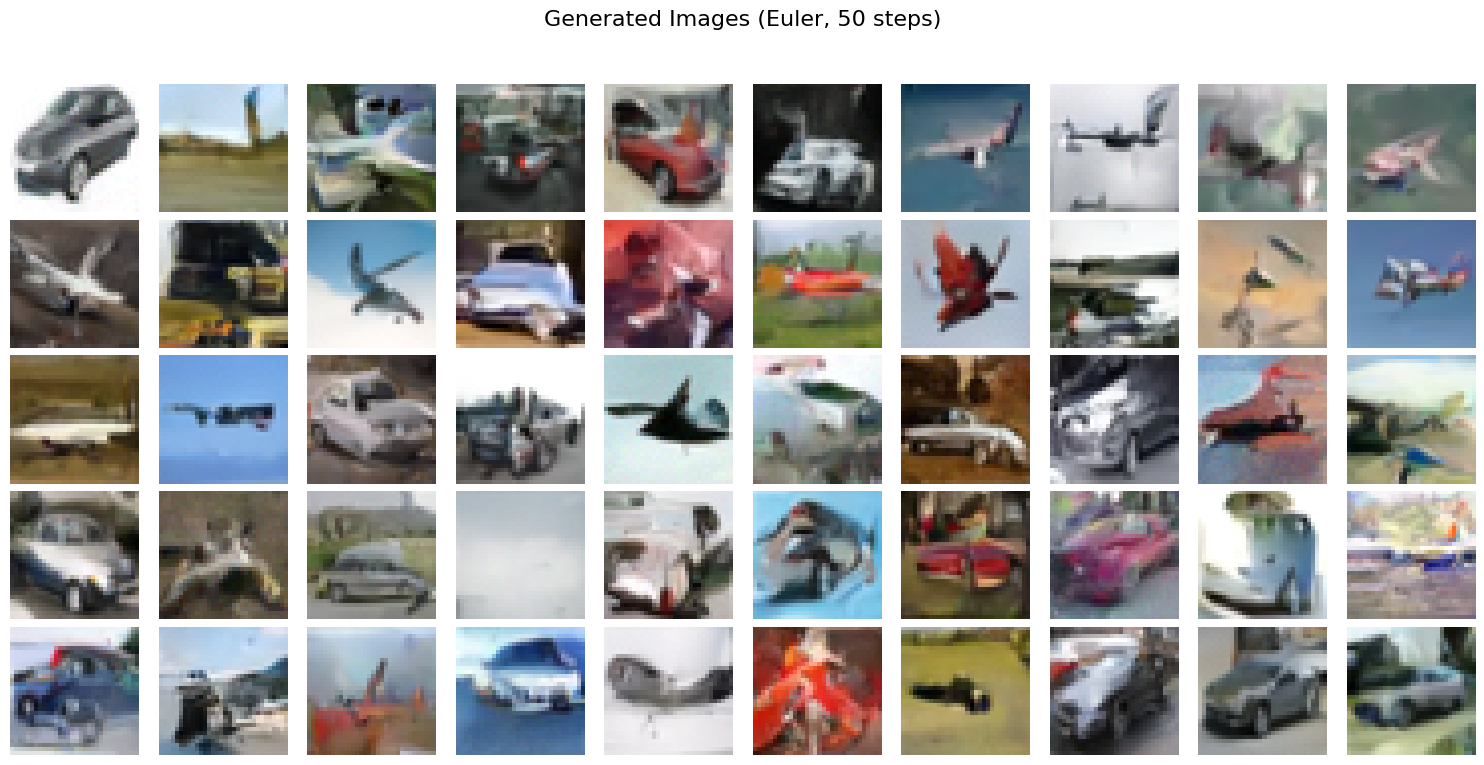

Sample generation complete.


In [16]:
print("Generating 50 samples with Euler (50 steps)...")
with torch.no_grad():
    samples = fm_loaded.sample_euler(
        batch_size=num_samples,
        num_steps=num_steps,
        img_size=img_size,
        channels=channels,
    )  # outputs in [-1, 1]

# Convert to [0,1] and numpy
samples = (samples.clamp(-1, 1) + 1) / 2
samples_np = samples.cpu().numpy()

# Showing 5x10 grid
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
axes = axes.flatten()

for i in range(num_samples):
    img = np.transpose(samples_np[i], (1, 2, 0))  # (H,W,C)
    axes[i].imshow(img)
    axes[i].axis("off")

plt.suptitle(f"Generated Images (Euler, {num_steps} steps)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Sample generation complete.")

#Computing FID Score at Eular stepp 10

In [20]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = data.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
        self.data = (self.data - 0.5) / 0.5  # [-1, 1]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx]), self.labels[idx]

def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f, encoding='bytes')

def load_cifar10_subset(cifar_path, selected_classes):
    """Load 2-class subset (coursework requirement)"""
    train_data = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(cifar_path, f'data_batch_{i}'))
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    train_data = np.vstack(train_data)
    train_labels = np.array(train_labels)

    # Filter for selected classes
    mask = np.isin(train_labels, selected_classes)
    train_data = train_data[mask]
    train_labels = train_labels[mask]

    # Remap labels
    label_map = {selected_classes[i]: i for i in range(len(selected_classes))}
    train_labels = np.array([label_map[l] for l in train_labels])

    # Test data
    test_batch = unpickle(os.path.join(cifar_path, 'test_batch'))
    test_data = test_batch[b'data']
    test_labels = np.array(test_batch[b'labels'])

    mask = np.isin(test_labels, selected_classes)
    test_data = test_data[mask]
    test_labels = test_labels[mask]
    test_labels = np.array([label_map[l] for l in test_labels])

    return train_data, train_labels, test_data, test_labels

print(" Dataset classes defined")


 Dataset classes defined


In [22]:
cifar_path = "/content/drive/MyDrive/cifar-10-batches-py"
_, _, test_data, _ = load_cifar10_subset(cifar_path, config.selected_classes)

val_data_for_fid = test_data[:config.fid_num_samples]
val_samples = torch.from_numpy(val_data_for_fid).float()
val_samples = (val_samples.reshape(-1, 3, 32, 32) / 255.0 - 0.5) / 0.5  # to [-1,1]

In [24]:
#Generating the same number of images with Euler using 10 steps
fid_step = 10
print(f"Generating {config.fid_num_samples} samples with Euler ({fid_step} steps)...")

all_gen = []
for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size)):
    gen = fm_loaded.sample_euler(
        batch_size=config.fid_batch_size,
        num_steps=fid_step,
        img_size=32,
        channels=3,
    )
    all_gen.append(gen.cpu())
    torch.cuda.empty_cache()

gen_samples = torch.cat(all_gen, dim=0)

Generating 2000 samples with Euler (10 steps)...


100%|██████████| 20/20 [00:23<00:00,  1.15s/it]


In [26]:
#Computing FID
fid_calc = FIDCalculator(device=device)
fid_score_10 = fid_calc.compute_fid(gen_samples.to(device), val_samples.to(device))
print(f"FID (Euler, {fid_step} steps): {fid_score_10:.2f}")

FID (Euler, 10 steps): 48.21
